Using device: cuda


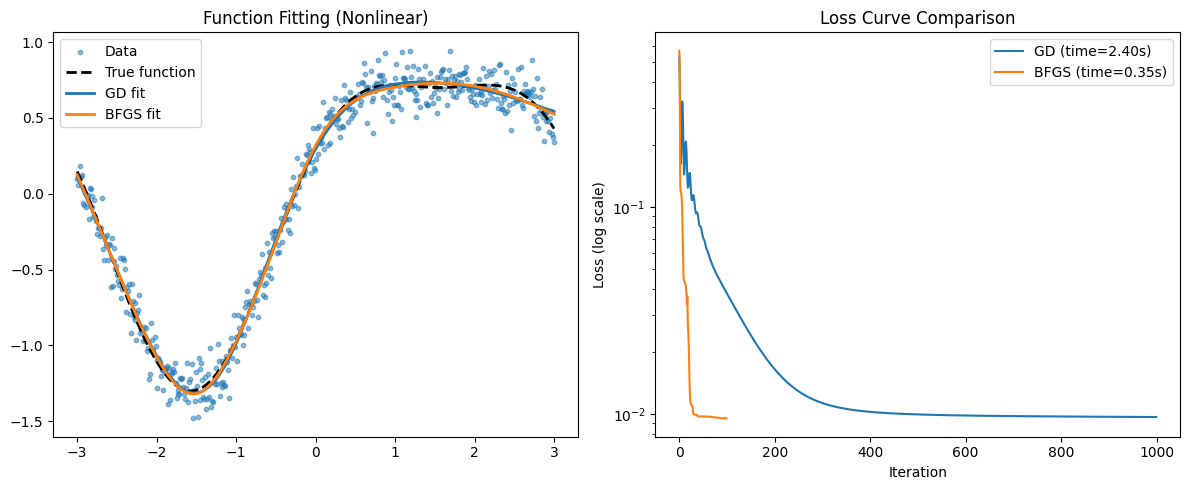

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# --- 生成非线性数据 ---
def make_nonlinear_data(n=500, d=1, noise=0.1):
    X = torch.linspace(-3, 3, n).reshape(-1, d)
    y = torch.sin(X) + 0.3 * torch.cos(2 * X) + noise * torch.randn_like(X)
    return X, y


X, y = make_nonlinear_data()
X, y = X.to(device), y.to(device)


# --- 定义一个小型神经网络模型 ---
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


# --- 训练函数 ---
def train(model, optimizer, max_iter=200, record_loss=True):
    model.train()
    losses = []
    start = time.time()
    for i in range(max_iter):
        optimizer.zero_grad()
        y_pred = model(X)
        loss = ((y_pred - y) ** 2).mean()
        loss.backward()
        optimizer.step()
        if record_loss:
            losses.append(loss.item())
    elapsed = time.time() - start
    return losses, elapsed


# --- 模型1：SGD ---
model_gd = MLP().to(device)
optimizer_gd = optim.SGD(model_gd.parameters(), lr=0.01, momentum=0.9)
losses_gd, time_gd = train(model_gd, optimizer_gd, max_iter=1000)

# --- 模型2：L-BFGS（拟牛顿法）---
model_bfgs = MLP().to(device)
optimizer_bfgs = optim.LBFGS(
    model_bfgs.parameters(), lr=0.8, max_iter=100, history_size=10
)

losses_bfgs = []
start = time.time()


def closure():
    optimizer_bfgs.zero_grad()
    y_pred = model_bfgs(X)
    loss = ((y_pred - y) ** 2).mean()
    loss.backward()
    losses_bfgs.append(loss.item())
    return loss


optimizer_bfgs.step(closure)
time_bfgs = time.time() - start

# --- 可视化结果 ---
with torch.no_grad():
    x_plot = torch.linspace(-3, 3, 500).reshape(-1, 1).to(device)
    y_true = torch.sin(x_plot) + 0.3 * torch.cos(2 * x_plot)
    y_gd = model_gd(x_plot)
    y_bfgs = model_bfgs(x_plot)

plt.figure(figsize=(12, 5))

# 拟合曲线
plt.subplot(1, 2, 1)
plt.scatter(X.cpu(), y.cpu(), s=10, alpha=0.5, label="Data")
plt.plot(x_plot.cpu(), y_true.cpu(), "k--", lw=2, label="True function")
plt.plot(x_plot.cpu(), y_gd.cpu(), "C0-", lw=2, label="GD fit")
plt.plot(x_plot.cpu(), y_bfgs.cpu(), "C1-", lw=2, label="BFGS fit")
plt.title("Function Fitting (Nonlinear)")
plt.legend()

# 损失曲线
plt.subplot(1, 2, 2)
plt.plot(losses_gd, label=f"GD (time={time_gd:.2f}s)")
plt.plot(losses_bfgs, label=f"BFGS (time={time_bfgs:.2f}s)")
plt.yscale("log")
plt.title("Loss Curve Comparison")
plt.xlabel("Iteration")
plt.ylabel("Loss (log scale)")
plt.legend()

plt.tight_layout()
plt.show()